In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

titanic=sb.load_dataset("titanic")
titanic.head()
titanic.info()
titanic.isnull().sum()

features=["age","sex","pclass","embarked","fare"]
target=["survived"]



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]= imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]= imp_freq.fit_transform(titanic[["embarked"]])  #simpleImputer needs dataframe , [[]] gives df

titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
#encoding after handling missing vals
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
labelEncoder=LabelEncoder()

titanic["sex"]=labelEncoder.fit_transform(titanic["sex"])
titanic["embarked"]=labelEncoder.fit_transform(titanic["embarked"])

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [ ]:
# feature 
from sklearn.model_selection import train_test_split
X=titanic[features]
y=titanic[target]

X_train,X_test,y_train, y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [ ]:
#Decision Tree without pruning
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("accuscore:", accuracy_score(y_pred,y_test))

accuscore: 0.770949720670391


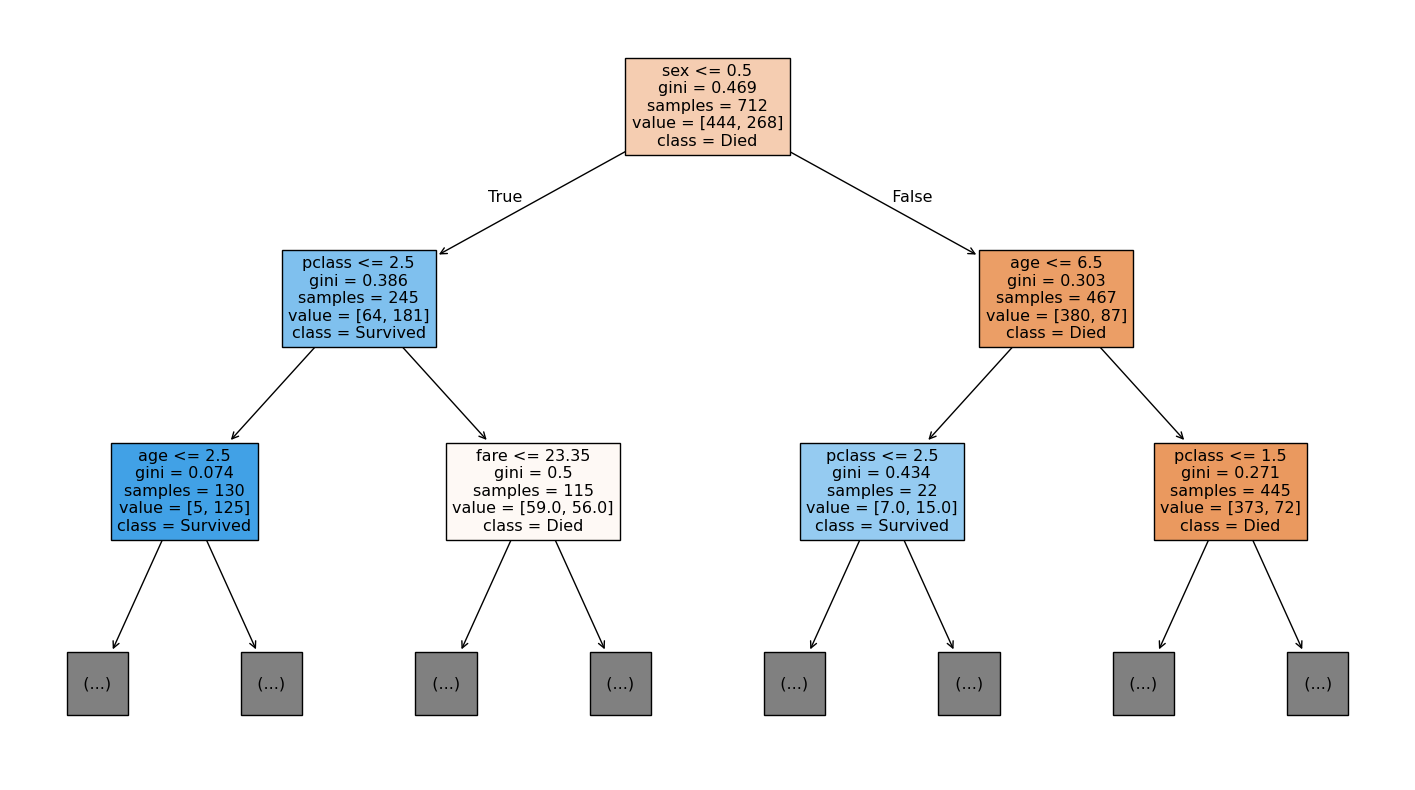

: 

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.show()

In [ ]:
max_depth=[1,2,3,4,5,6]
for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print("for depth={depth},accuracy score={acc}")